# EDA: Feature Correlation and Lag Analysis

Exploratory analysis of the assembled feature matrix against CDFA vintage targets (Brix, tons crushed). Results directly inform:
- Which features to include in the gradient boosting model (#38)
- Whether lag-1 climate features add signal (LSTM decision)
- The train/test split year

**Data sources:**
- `data/processed/feature_matrix.parquet` — 578 rows, 34 years × 17 AVAs, 20 columns
- `data/processed/cdfa_clean.parquet` — 105 rows, 35 years × 3 varieties (district 4, Napa)

**Join strategy:** CDFA targets are district-level (all Napa). Features are joined by year using the `Napa Valley` AVA row from the feature matrix, which represents the broadest Napa-wide aggregate.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

ROOT = Path("..") if Path("../data").exists() else Path(".")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

VARIETIES = ["Cabernet Sauvignon", "Pinot Noir", "Chardonnay"]
VAR_COLORS = {
    "Cabernet Sauvignon": "#7B2D8B",
    "Pinot Noir":         "#C0392B",
    "Chardonnay":         "#D4AC0D",
}

In [ ]:
# Load and join data
features_raw = pd.read_parquet(ROOT / "data/processed/feature_matrix.parquet")
cdfa = pd.read_parquet(ROOT / "data/processed/cdfa_clean.parquet")

# Use the Napa Valley AVA row as the district-level feature representative
features_napa = features_raw[features_raw["ava_district"] == "Napa Valley"].copy()
features_napa = features_napa.drop(columns=["ava_district"])

# Drop categorical soil columns for numeric analysis; keep severity_score
features_napa = features_napa.drop(columns=["drainagecl", "texcl", "stations_used", "drought_class"], errors="ignore")

# Join: one row per (year × variety)
df = cdfa.merge(features_napa, on="year", how="inner")

print(f"Joined dataset: {len(df)} rows | {df['year'].nunique()} years | {df['variety'].nunique()} varieties")
print(f"Year range: {df['year'].min()}–{df['year'].max()}")
print(f"Columns: {list(df.columns)}")
df.head()

Joined dataset: 102 rows | 34 years | 3 varieties
Year range: 1991–2024
Columns: ['year', 'variety', 'district', 'tons_crushed', 'brix', 'price_per_ton', 'brix_available', 'gdd', 'winkler_index', 'frost_days', 'heat_stress_days', 'tmax_veraison', 'precip_winter', 'missing_days_growing', 'data_quality_warn', 'eto_season', 'eto_days', 'severity_score', 'is_dry', 'awc_r', 'claytotal_r']


,year,variety,district,tons_crushed,brix,price_per_ton,brix_available,gdd,winkler_index,frost_days,...,tmax_veraison,precip_winter,missing_days_growing,data_quality_warn,eto_season,eto_days,severity_score,is_dry,awc_r,claytotal_r
0,1991,Cabernet Sauvignon,4,31946.5,23.0,1688.89,True,1815.2,1815.2,0,...,30.18,517.8,0,False,38.82,214,1,True,0.115449,27.104655
1,1991,Chardonnay,4,41034.9,22.5,1491.11,True,1815.2,1815.2,0,...,30.18,517.8,0,False,38.82,214,1,True,0.115449,27.104655
2,1991,Pinot Noir,4,10857.0,20.8,966.85,True,1815.2,1815.2,0,...,30.18,517.8,0,False,38.82,214,1,True,0.115449,27.104655
3,1992,Cabernet Sauvignon,4,33315.7,23.3,1636.88,True,2086.7,2086.7,0,...,31.37,616.4,0,False,40.45,214,1,True,0.115449,27.104655
4,1992,Chardonnay,4,38822.3,22.9,1435.53,True,2086.7,2086.7,0,...,31.37,616.4,0,False,40.45,214,1,True,0.115449,27.104655


---
## 1. Target Distributions

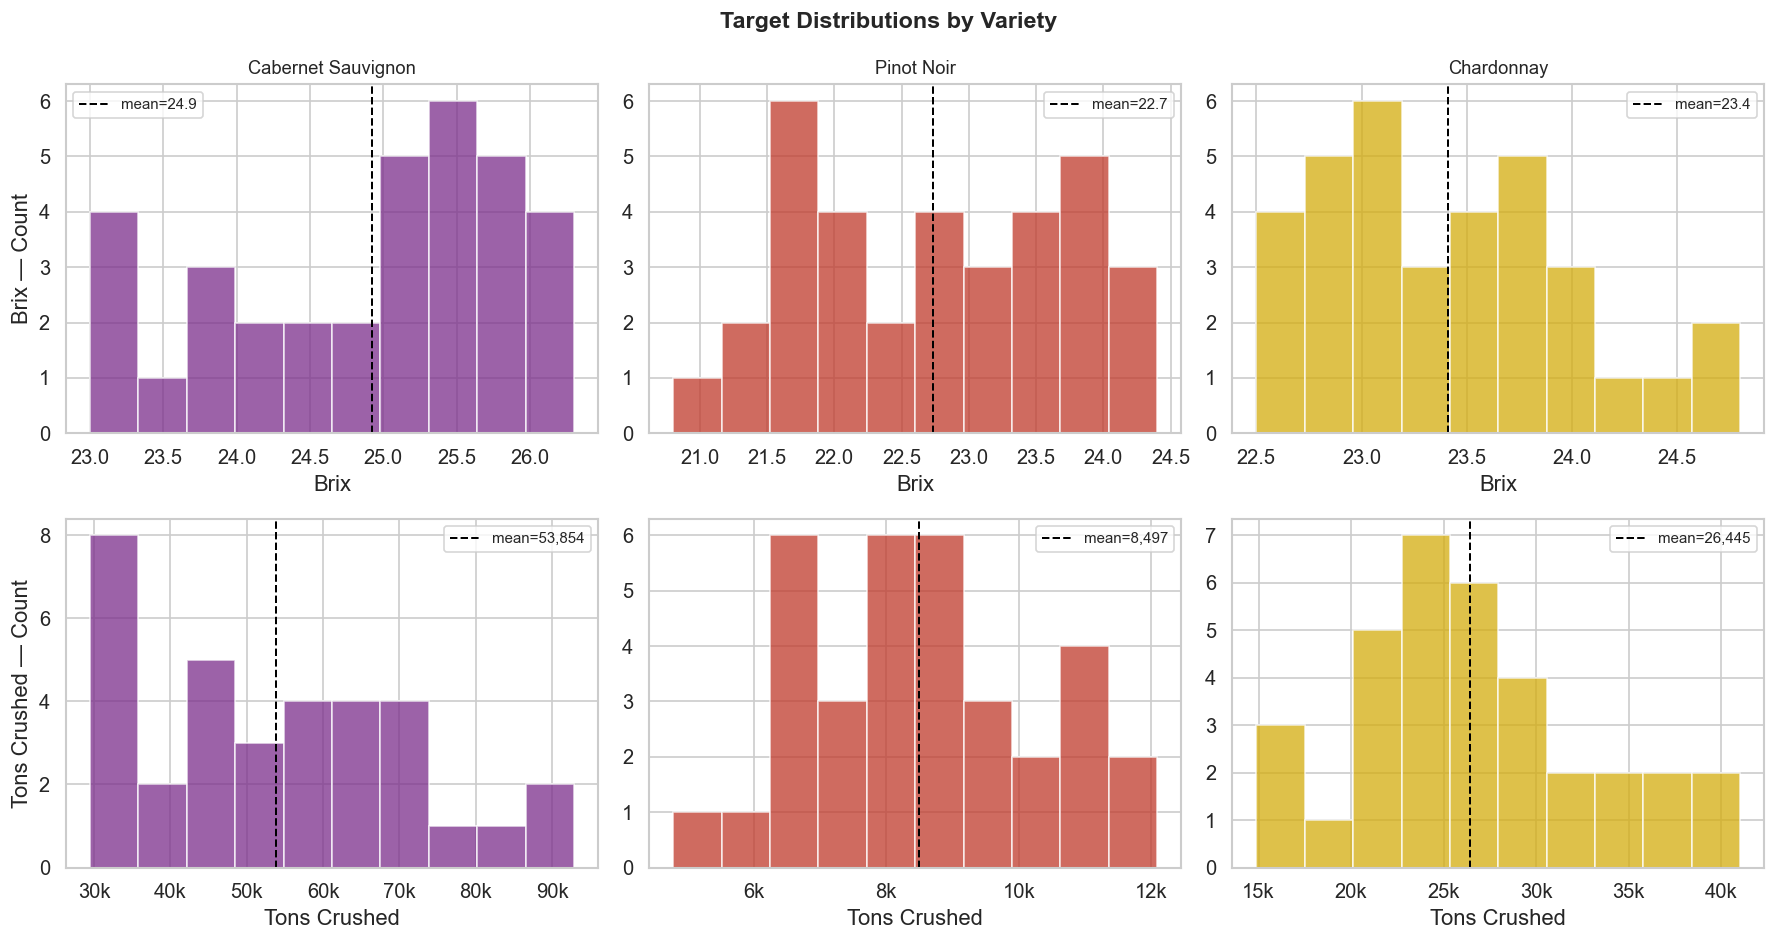

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Target Distributions by Variety", fontsize=14, fontweight="bold")

for col_idx, variety in enumerate(VARIETIES):
    sub = df[df["variety"] == variety]
    color = VAR_COLORS[variety]

    # Brix histogram
    axes[0, col_idx].hist(sub["brix"].dropna(), bins=10, color=color, alpha=0.75, edgecolor="white")
    axes[0, col_idx].axvline(sub["brix"].mean(), color="black", linestyle="--", linewidth=1.2, label=f"mean={sub['brix'].mean():.1f}")
    axes[0, col_idx].set_title(variety, fontsize=11)
    axes[0, col_idx].set_xlabel("Brix")
    axes[0, col_idx].set_ylabel("Count" if col_idx == 0 else "")
    axes[0, col_idx].legend(fontsize=9)

    # Tons crushed histogram
    axes[1, col_idx].hist(sub["tons_crushed"].dropna(), bins=10, color=color, alpha=0.75, edgecolor="white")
    axes[1, col_idx].axvline(sub["tons_crushed"].mean(), color="black", linestyle="--", linewidth=1.2, label=f"mean={sub['tons_crushed'].mean():,.0f}")
    axes[1, col_idx].set_xlabel("Tons Crushed")
    axes[1, col_idx].set_ylabel("Count" if col_idx == 0 else "")
    axes[1, col_idx].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    axes[1, col_idx].legend(fontsize=9)

axes[0, 0].set_ylabel("Brix — Count")
axes[1, 0].set_ylabel("Tons Crushed — Count")
plt.tight_layout()
plt.show()

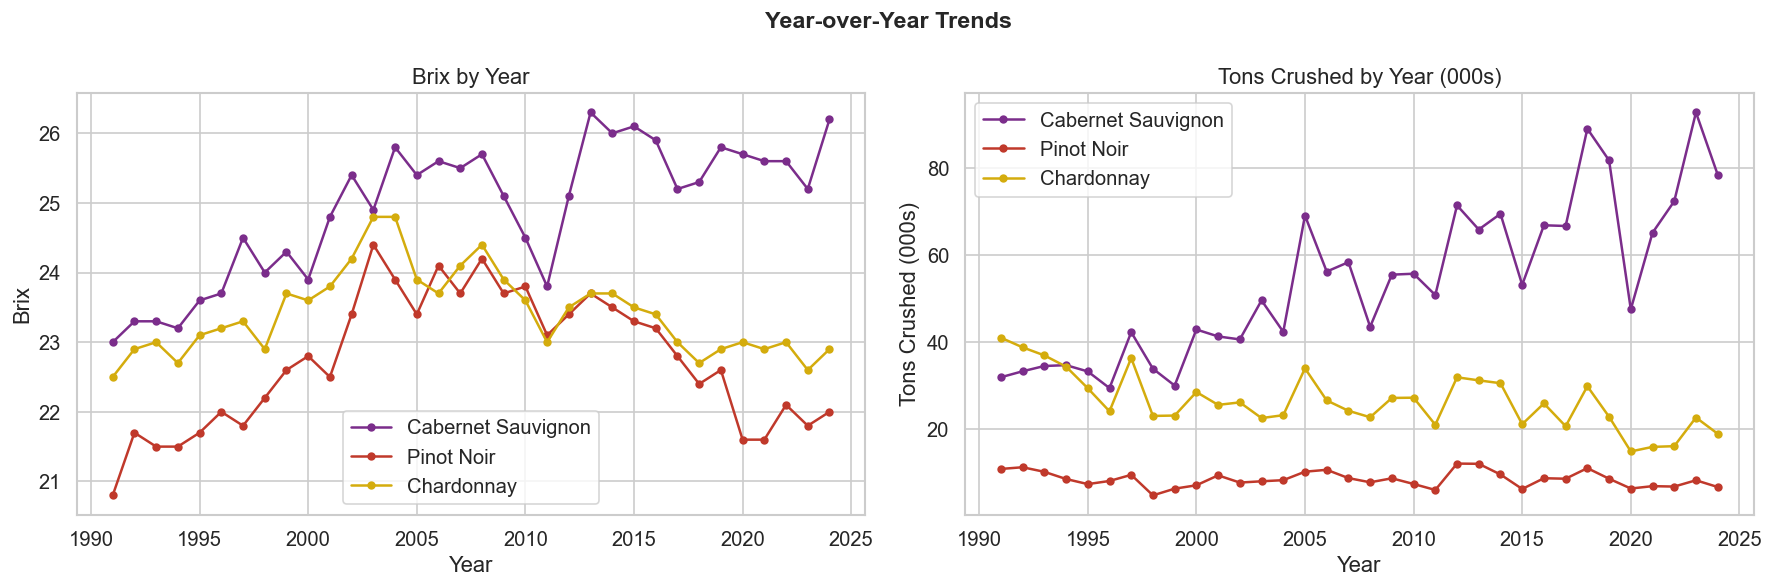

Outlier years (Brix > 2σ from variety mean):
  Cabernet Sauvignon: none
  Pinot Noir: [{'year': 1991, 'brix': 20.8}]
  Chardonnay: [{'year': 2003, 'brix': 24.8}, {'year': 2004, 'brix': 24.8}]


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Year-over-Year Trends", fontsize=14, fontweight="bold")

for variety in VARIETIES:
    sub = df[df["variety"] == variety].sort_values("year")
    color = VAR_COLORS[variety]
    axes[0].plot(sub["year"], sub["brix"], marker="o", markersize=4, color=color, label=variety, linewidth=1.5)
    axes[1].plot(sub["year"], sub["tons_crushed"] / 1000, marker="o", markersize=4, color=color, label=variety, linewidth=1.5)

axes[0].set_title("Brix by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Brix")
axes[0].legend()

axes[1].set_title("Tons Crushed by Year (000s)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Tons Crushed (000s)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Flag outlier years (Brix > 2 std dev from variety mean)
print("Outlier years (Brix > 2σ from variety mean):")
for variety in VARIETIES:
    sub = df[df["variety"] == variety]
    mu, sigma = sub["brix"].mean(), sub["brix"].std()
    outliers = sub[np.abs(sub["brix"] - mu) > 2 * sigma][["year", "brix"]]
    if not outliers.empty:
        print(f"  {variety}: {outliers.to_dict('records')}")
    else:
        print(f"  {variety}: none")

---
## 2. Feature–Target Correlations

/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(valid[feat], valid[tgt])
/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(valid[feat], valid[tgt])
/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(valid[feat], valid[tgt])
/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(valid[feat], valid[tgt])
/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:20: ConstantInputWarni

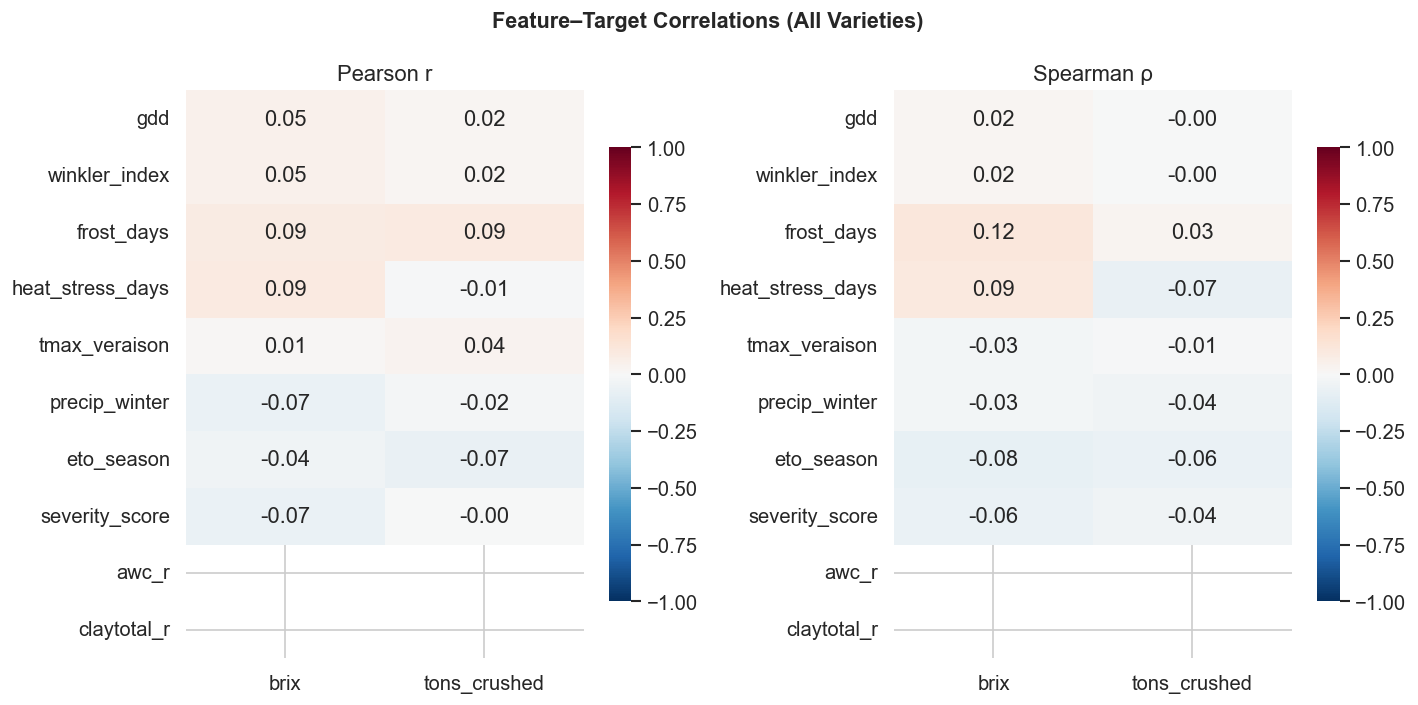

In [5]:
CLIMATE_FEATURES = [
    "gdd", "winkler_index", "frost_days", "heat_stress_days",
    "tmax_veraison", "precip_winter", "eto_season", "severity_score",
    "awc_r", "claytotal_r",
]
TARGETS = ["brix", "tons_crushed"]

def correlation_matrix(data: pd.DataFrame, features: list, targets: list, method: str) -> pd.DataFrame:
    rows = []
    for feat in features:
        row = {}
        for tgt in targets:
            valid = data[[feat, tgt]].dropna()
            if len(valid) < 5:
                row[tgt] = np.nan
                continue
            if method == "pearson":
                r, _ = stats.pearsonr(valid[feat], valid[tgt])
            else:
                r, _ = stats.spearmanr(valid[feat], valid[tgt])
            row[tgt] = round(r, 3)
        rows.append(row)
    return pd.DataFrame(rows, index=features)

pearson_all  = correlation_matrix(df, CLIMATE_FEATURES, TARGETS, "pearson")
spearman_all = correlation_matrix(df, CLIMATE_FEATURES, TARGETS, "spearman")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Feature–Target Correlations (All Varieties)", fontsize=13, fontweight="bold")

sns.heatmap(pearson_all, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Pearson r")

sns.heatmap(spearman_all, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Spearman ρ")

plt.tight_layout()
plt.show()

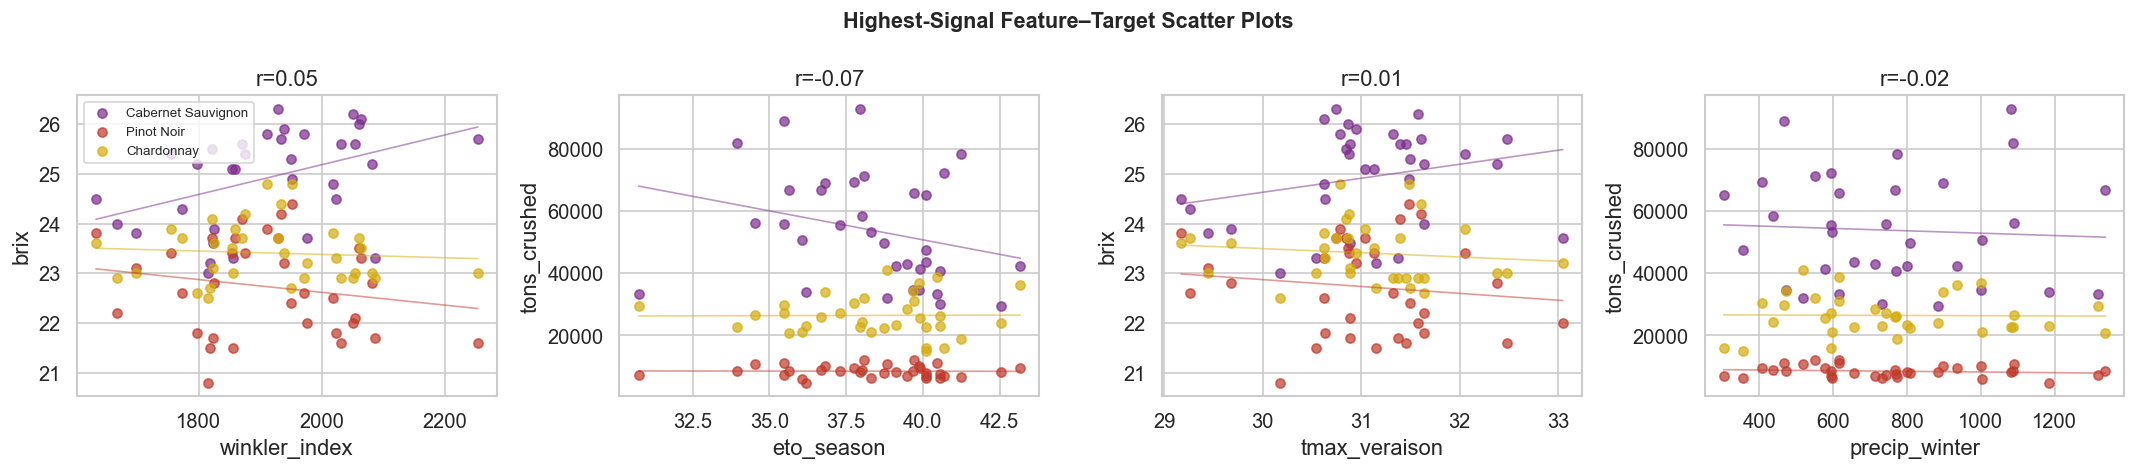

In [6]:
# Scatter plots for highest-signal pairs
high_signal_pairs = [
    ("winkler_index", "brix"),
    ("eto_season", "tons_crushed"),
    ("tmax_veraison", "brix"),
    ("precip_winter", "tons_crushed"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Highest-Signal Feature–Target Scatter Plots", fontsize=13, fontweight="bold")

for ax, (feat, tgt) in zip(axes, high_signal_pairs):
    for variety in VARIETIES:
        sub = df[df["variety"] == variety][[feat, tgt]].dropna()
        ax.scatter(sub[feat], sub[tgt], color=VAR_COLORS[variety], alpha=0.7, s=30, label=variety)
        if len(sub) > 2:
            m, b = np.polyfit(sub[feat], sub[tgt], 1)
            x_line = np.linspace(sub[feat].min(), sub[feat].max(), 50)
            ax.plot(x_line, m * x_line + b, color=VAR_COLORS[variety], linewidth=1, alpha=0.5)
    ax.set_xlabel(feat)
    ax.set_ylabel(tgt)
    r, _ = stats.pearsonr(df[feat].dropna(), df[tgt].loc[df[feat].dropna().index])
    ax.set_title(f"r={r:.2f}")

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(valid[feat], valid[tgt])
/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(valid[feat], valid[tgt])
/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(valid[feat], valid[tgt])
/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(valid[feat], valid[tgt])
/var/folders/32/n_0pc3t90kz7dly24g_p64740000gn/T/ipykernel_76681/412425542.py:18: ConstantInputWarni

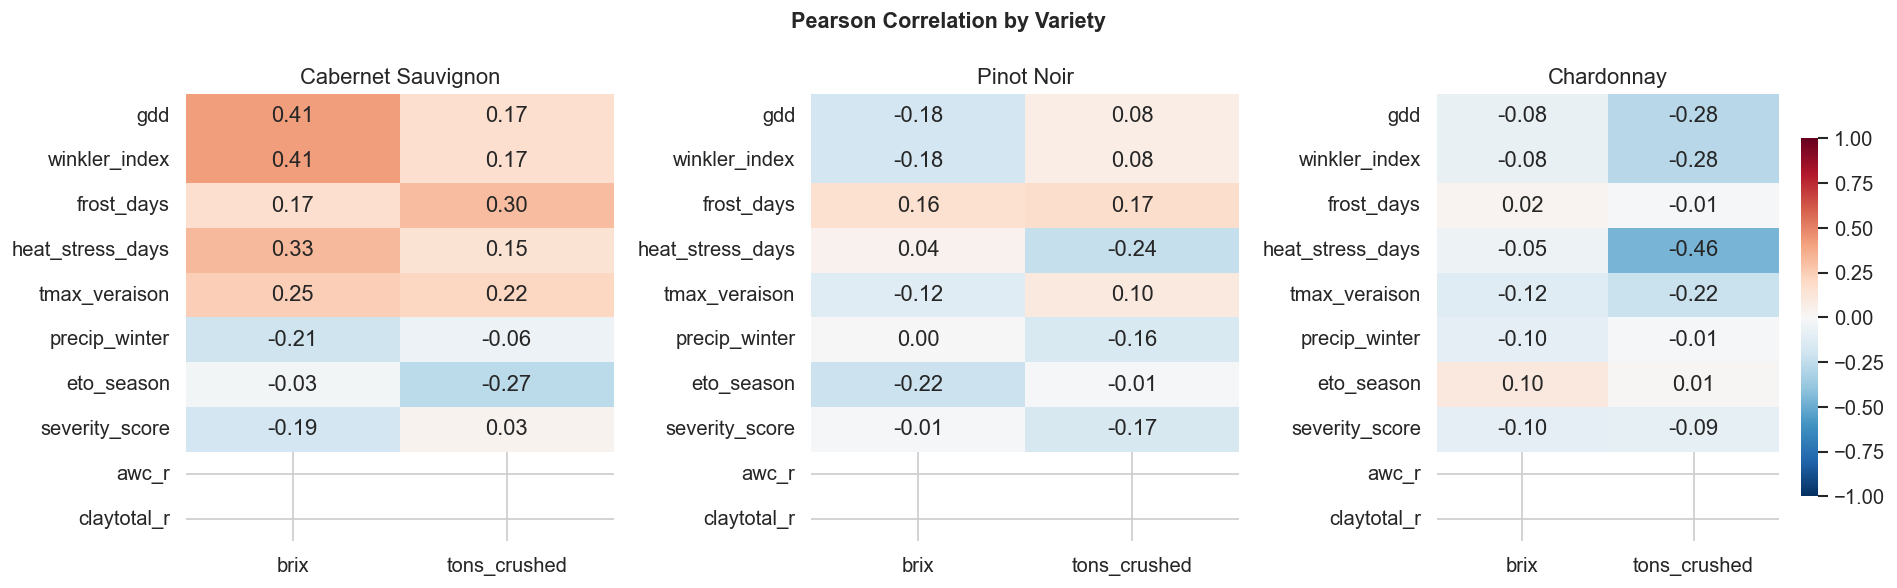

In [7]:
# Variety-specific correlation breakdown
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Pearson Correlation by Variety", fontsize=13, fontweight="bold")

for ax, variety in zip(axes, VARIETIES):
    sub = df[df["variety"] == variety]
    corr = correlation_matrix(sub, CLIMATE_FEATURES, TARGETS, "pearson")
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, ax=ax, cbar=(variety == "Chardonnay"),
                cbar_kws={"shrink": 0.8})
    ax.set_title(variety)

plt.tight_layout()
plt.show()

---
## 3. Lag Correlation Analysis

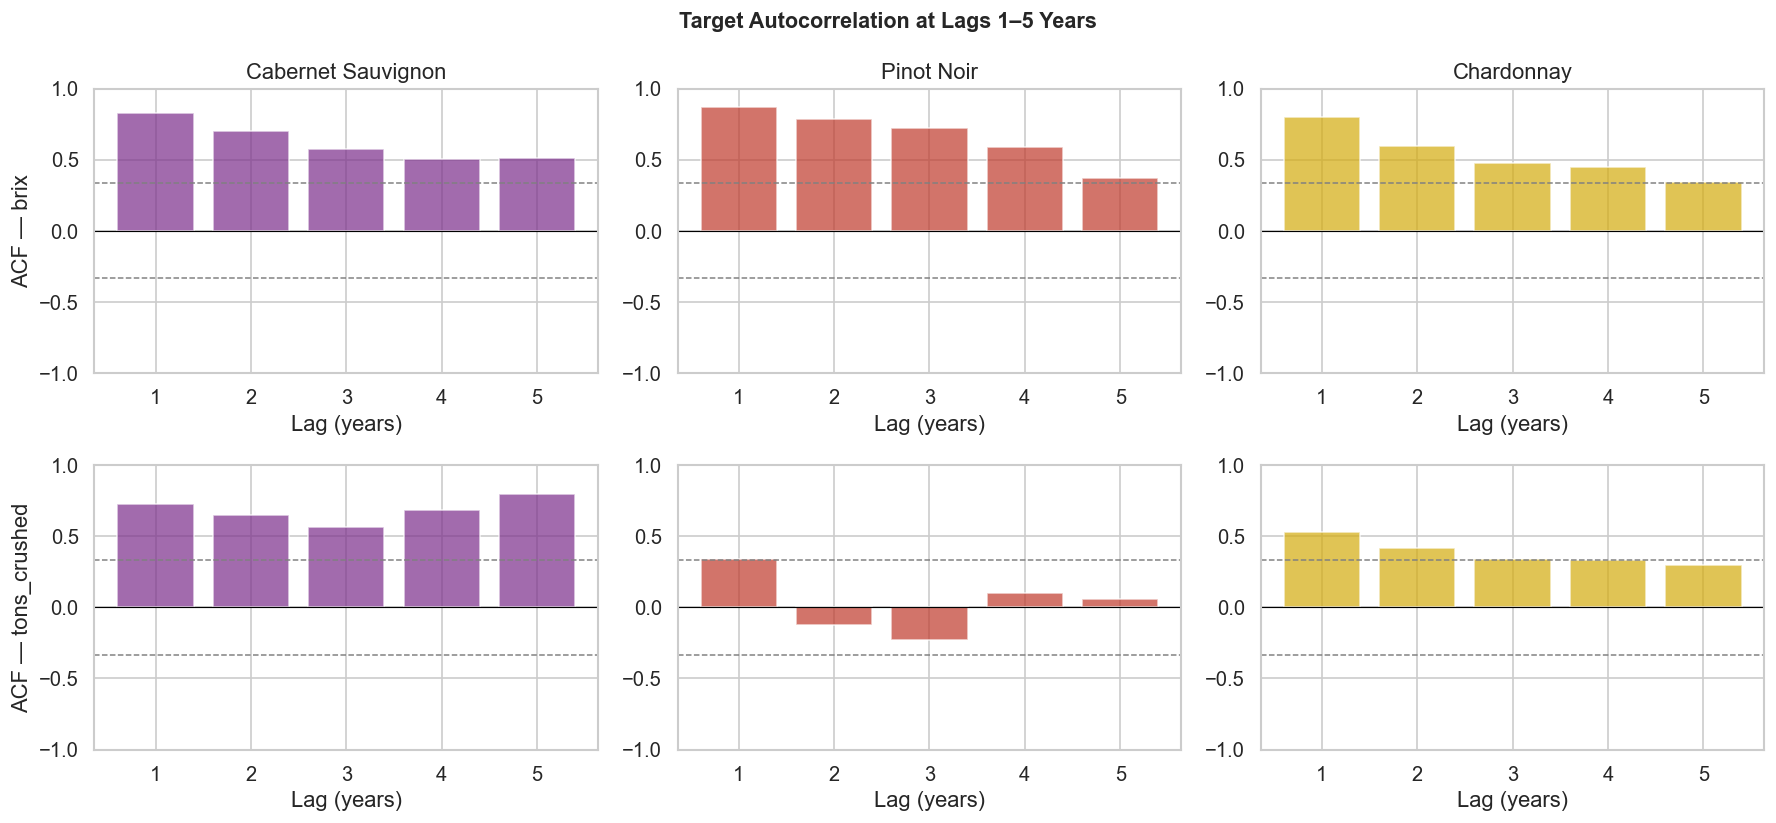

In [8]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle("Target Autocorrelation at Lags 1–5 Years", fontsize=13, fontweight="bold")

MAX_LAG = 5

for col_idx, variety in enumerate(VARIETIES):
    sub = df[df["variety"] == variety].sort_values("year")
    color = VAR_COLORS[variety]

    for row_idx, tgt in enumerate(TARGETS):
        ax = axes[row_idx, col_idx]
        series = sub.set_index("year")[tgt].dropna()
        lags = range(1, MAX_LAG + 1)
        acf_vals = [series.autocorr(lag=lag) for lag in lags]
        bars = ax.bar(lags, acf_vals, color=color, alpha=0.7, edgecolor="white")
        # 95% confidence band: ±1.96/sqrt(n)
        ci = 1.96 / np.sqrt(len(series))
        ax.axhline(ci, color="gray", linestyle="--", linewidth=0.9)
        ax.axhline(-ci, color="gray", linestyle="--", linewidth=0.9)
        ax.axhline(0, color="black", linewidth=0.7)
        ax.set_ylim(-1, 1)
        ax.set_xticks(list(lags))
        ax.set_xlabel("Lag (years)")
        ax.set_ylabel(f"ACF — {tgt}" if col_idx == 0 else "")
        ax.set_title(variety if row_idx == 0 else "")

plt.tight_layout()
plt.show()

In [9]:
# Cross-correlation: key climate features vs targets at lag 0 and lag 1
LAG_FEATURES = ["winkler_index", "eto_season", "precip_winter", "tmax_veraison", "severity_score"]

print("Cross-correlation: feature vs target at lag 0 and lag 1")
print(f"{'Feature':<20} {'Target':<15} {'Variety':<22} {'lag-0 r':>8} {'lag-1 r':>8} {'Δ':>8}")
print("-" * 85)

lag1_results = []

for variety in VARIETIES:
    sub = df[df["variety"] == variety].sort_values("year").copy()
    for feat in LAG_FEATURES:
        for tgt in TARGETS:
            valid0 = sub[[feat, tgt]].dropna()
            r0, _ = stats.pearsonr(valid0[feat], valid0[tgt]) if len(valid0) > 4 else (np.nan, np.nan)

            # Lag-1: shift feature back one year (feature from year t-1 predicts target in year t)
            sub[f"{feat}_lag1"] = sub[feat].shift(1)
            valid1 = sub[[f"{feat}_lag1", tgt]].dropna()
            r1, _ = stats.pearsonr(valid1[f"{feat}_lag1"], valid1[tgt]) if len(valid1) > 4 else (np.nan, np.nan)

            delta = r1 - r0 if not (np.isnan(r0) or np.isnan(r1)) else np.nan
            print(f"{feat:<20} {tgt:<15} {variety:<22} {r0:>8.3f} {r1:>8.3f} {delta:>8.3f}")
            lag1_results.append({"feature": feat, "target": tgt, "variety": variety,
                                  "r_lag0": r0, "r_lag1": r1, "delta": delta})
    print()

lag1_df = pd.DataFrame(lag1_results)

Cross-correlation: feature vs target at lag 0 and lag 1
Feature              Target          Variety                 lag-0 r  lag-1 r        Δ
-------------------------------------------------------------------------------------
winkler_index        brix            Cabernet Sauvignon        0.415    0.297   -0.118
winkler_index        tons_crushed    Cabernet Sauvignon        0.166    0.293    0.126
eto_season           brix            Cabernet Sauvignon       -0.026   -0.123   -0.097
eto_season           tons_crushed    Cabernet Sauvignon       -0.272   -0.095    0.177
precip_winter        brix            Cabernet Sauvignon       -0.207   -0.176    0.031
precip_winter        tons_crushed    Cabernet Sauvignon       -0.058   -0.099   -0.041
tmax_veraison        brix            Cabernet Sauvignon        0.247    0.311    0.064
tmax_veraison        tons_crushed    Cabernet Sauvignon        0.216    0.191   -0.025
severity_score       brix            Cabernet Sauvignon       -0.186   -0.0

---
## 4. Water Year Signal

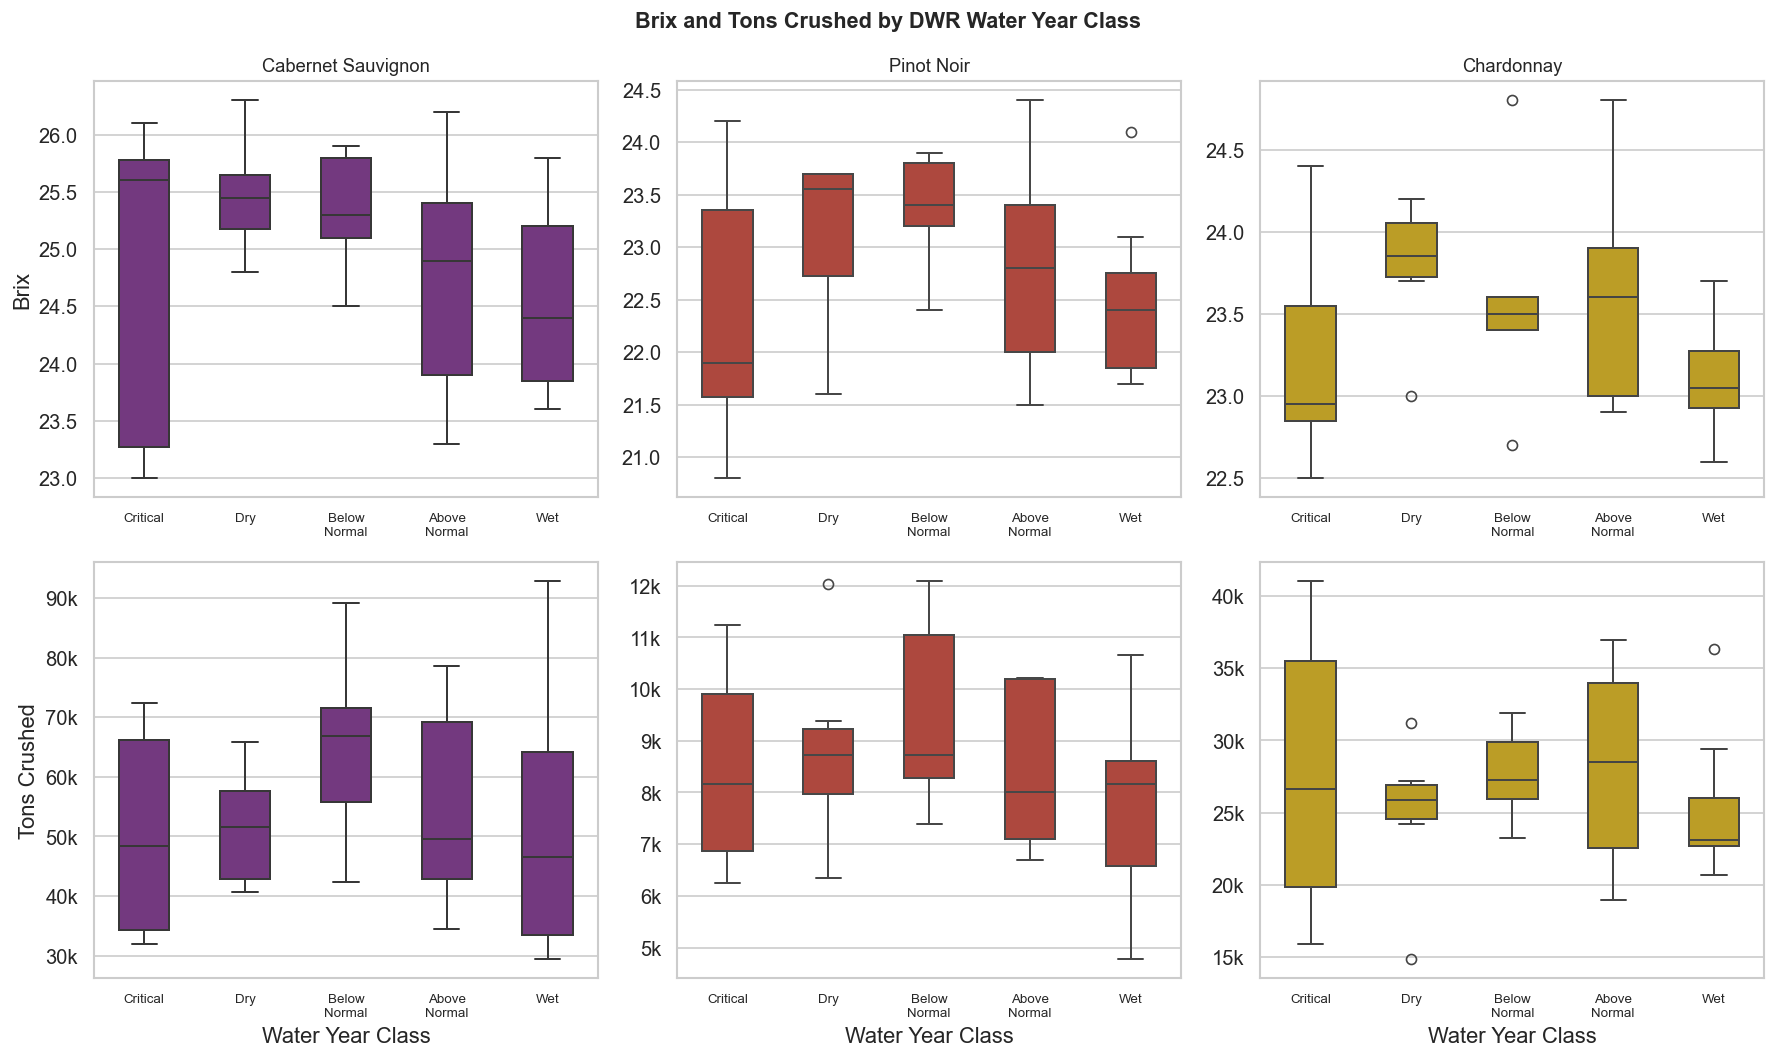

Mann-Whitney U test: D/C years vs W/AN years
Variety                Target            D/C median  W/AN median    p-value  Significant?
------------------------------------------------------------------------------------------
Cabernet Sauvignon     brix                    25.6         25.0      0.293            No
Cabernet Sauvignon     tons_crushed         50378.9      53299.3      0.564            No
Pinot Noir             brix                    22.9         22.7      0.739            No
Pinot Noir             tons_crushed          8625.0       8263.2      0.740            No
Chardonnay             brix                    23.6         23.2      0.623            No
Chardonnay             tons_crushed         25876.7      25018.3      0.986            No


In [10]:
# Re-attach drought_class for this section
# Note: is_dry is already in df from the feature matrix join; only pull drought_class to avoid column collision
dwr_cols = features_raw[features_raw["ava_district"] == "Napa Valley"][["year", "drought_class"]]
df_dwr = df.merge(dwr_cols, on="year", how="left")

CLASS_ORDER = ["C", "D", "BN", "AN", "W"]
CLASS_LABELS = {"C": "Critical", "D": "Dry", "BN": "Below\nNormal", "AN": "Above\nNormal", "W": "Wet"}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Brix and Tons Crushed by DWR Water Year Class", fontsize=13, fontweight="bold")

for col_idx, variety in enumerate(VARIETIES):
    sub = df_dwr[df_dwr["variety"] == variety].copy()
    sub["drought_class"] = pd.Categorical(sub["drought_class"], categories=CLASS_ORDER, ordered=True)
    color = VAR_COLORS[variety]

    sns.boxplot(data=sub, x="drought_class", y="brix", order=CLASS_ORDER,
                color=color, ax=axes[0, col_idx], width=0.5, linewidth=1.2)
    axes[0, col_idx].set_title(variety, fontsize=11)
    axes[0, col_idx].set_xlabel("")
    axes[0, col_idx].set_ylabel("Brix" if col_idx == 0 else "")
    axes[0, col_idx].set_xticks(range(len(CLASS_ORDER)))
    axes[0, col_idx].set_xticklabels([CLASS_LABELS[c] for c in CLASS_ORDER], fontsize=8)

    sns.boxplot(data=sub, x="drought_class", y="tons_crushed", order=CLASS_ORDER,
                color=color, ax=axes[1, col_idx], width=0.5, linewidth=1.2)
    axes[1, col_idx].set_xlabel("Water Year Class")
    axes[1, col_idx].set_ylabel("Tons Crushed" if col_idx == 0 else "")
    axes[1, col_idx].set_xticks(range(len(CLASS_ORDER)))
    axes[1, col_idx].set_xticklabels([CLASS_LABELS[c] for c in CLASS_ORDER], fontsize=8)
    axes[1, col_idx].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
plt.show()

# Are D/C years distinguishable from W/AN? Mann-Whitney U test
print("Mann-Whitney U test: D/C years vs W/AN years")
print(f"{'Variety':<22} {'Target':<15} {'D/C median':>12} {'W/AN median':>12} {'p-value':>10} {'Significant?':>13}")
print("-" * 90)
for variety in VARIETIES:
    sub = df_dwr[df_dwr["variety"] == variety]
    for tgt in TARGETS:
        dry = sub[sub["is_dry"] == True][tgt].dropna()
        wet = sub[sub["is_dry"] == False][tgt].dropna()
        if len(dry) > 1 and len(wet) > 1:
            u_stat, p_val = stats.mannwhitneyu(dry, wet, alternative="two-sided")
            sig = "Yes *" if p_val < 0.05 else "No"
            print(f"{variety:<22} {tgt:<15} {dry.median():>12.1f} {wet.median():>12.1f} {p_val:>10.3f} {sig:>13}")

---
## 5. Train/Test Split Selection

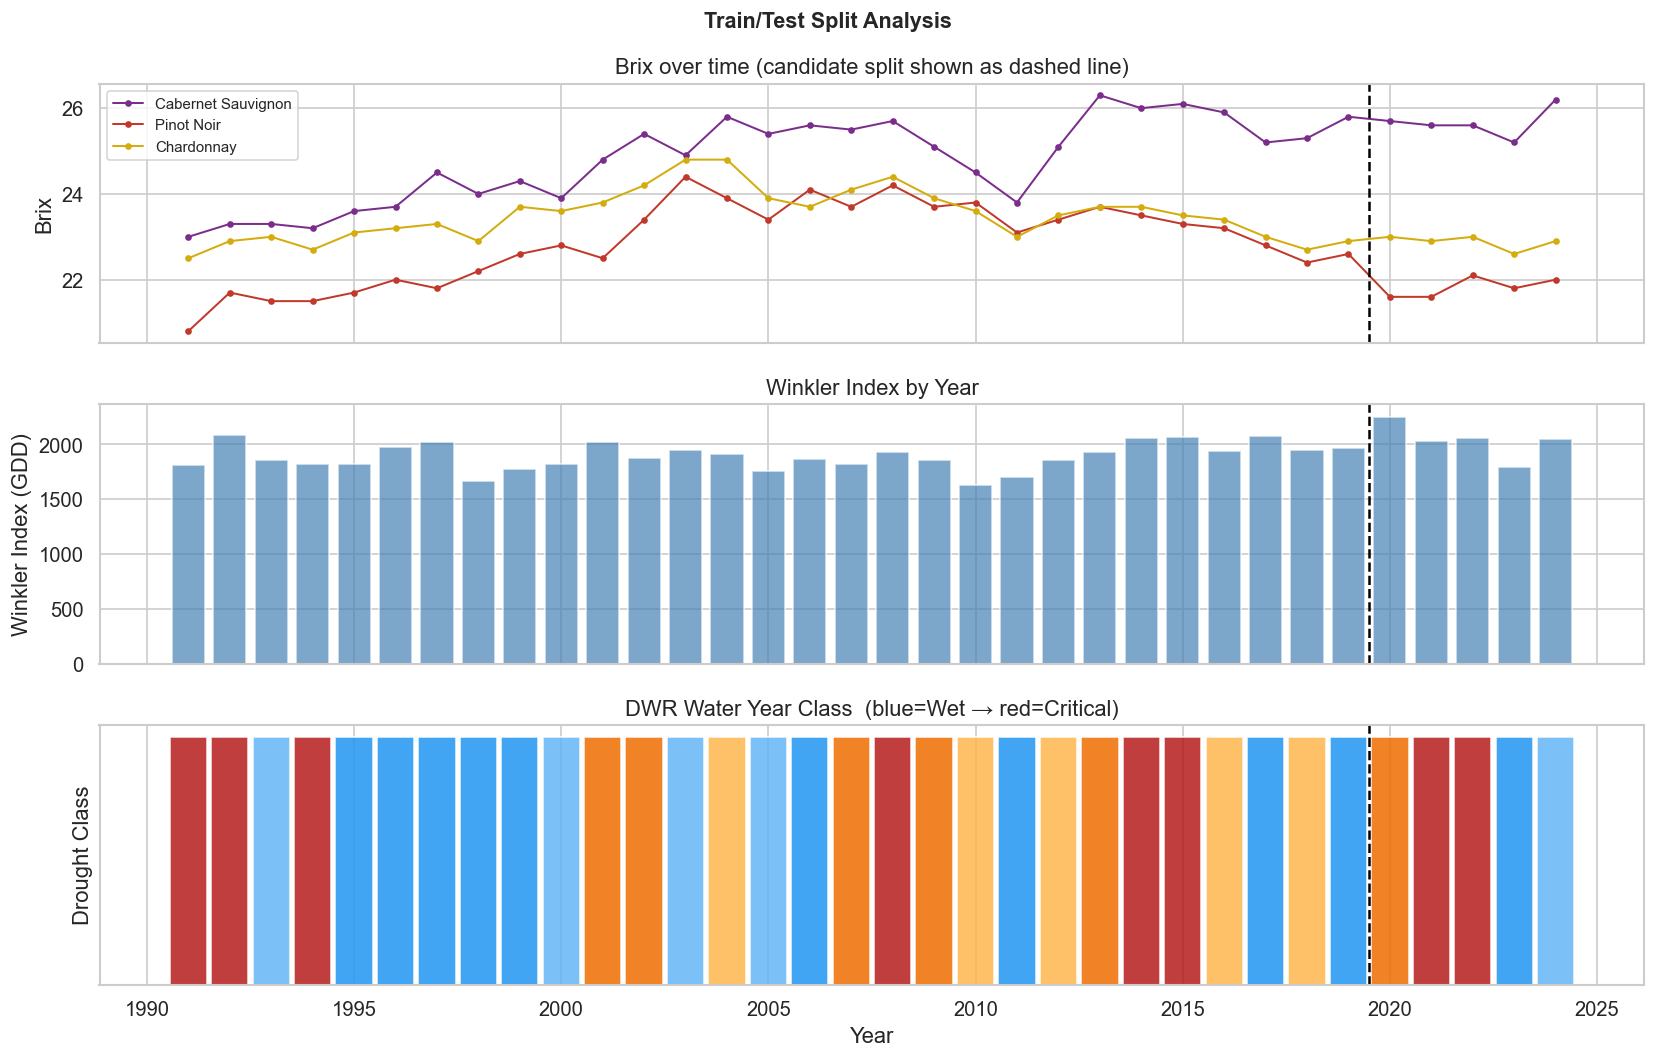

Candidate split year: 2019
  Train: 29 years (1991–2019)
  Test : 5 years (2020–2024)


In [11]:
# Show data density and structural breaks across the full range
year_counts = df.groupby("year").size().reset_index(name="n_rows")
brix_cv = df.groupby("year")["brix"].std() / df.groupby("year")["brix"].mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle("Train/Test Split Analysis", fontsize=13, fontweight="bold")

# Row 0: Brix by variety over time
for variety in VARIETIES:
    sub = df[df["variety"] == variety].sort_values("year")
    axes[0].plot(sub["year"], sub["brix"], marker="o", markersize=3,
                 color=VAR_COLORS[variety], label=variety, linewidth=1.2)
axes[0].set_ylabel("Brix")
axes[0].legend(fontsize=9)
axes[0].set_title("Brix over time (candidate split shown as dashed line)")

# Row 1: Winkler index (primary climate driver)
napa_feats = features_raw[features_raw["ava_district"] == "Napa Valley"].sort_values("year")
axes[1].bar(napa_feats["year"], napa_feats["winkler_index"], color="steelblue", alpha=0.7)
axes[1].set_ylabel("Winkler Index (GDD)")
axes[1].set_title("Winkler Index by Year")

# Row 2: DWR drought classification coloured bar
drought_color_map = {"W": "#2196F3", "AN": "#64B5F6", "BN": "#FFB74D", "D": "#EF6C00", "C": "#B71C1C"}
for _, row in dwr_cols.iterrows():
    c = drought_color_map.get(row["drought_class"], "gray")
    axes[2].bar(row["year"], 1, color=c, alpha=0.85, width=0.9)
axes[2].set_ylabel("Drought Class")
axes[2].set_yticks([])
axes[2].set_title("DWR Water Year Class  (blue=Wet → red=Critical)")

# Candidate split
SPLIT_YEAR = 2019
for ax in axes:
    ax.axvline(SPLIT_YEAR + 0.5, color="black", linestyle="--", linewidth=1.5)

axes[2].set_xlabel("Year")
plt.tight_layout()
plt.show()

n_train = df[df["year"] <= SPLIT_YEAR]["year"].nunique()
n_test  = df[df["year"] >  SPLIT_YEAR]["year"].nunique()
print(f"Candidate split year: {SPLIT_YEAR}")
print(f"  Train: {n_train} years ({df['year'].min()}–{SPLIT_YEAR})")
print(f"  Test : {n_test} years ({SPLIT_YEAR + 1}–{df['year'].max()})")

---
## Summary and Decisions

### Recommended Train/Test Split

**Split year: 2019** — train 1991–2019 (29 years), test 2020–2024 (5 years).

Rationale:
- 29 training years covers all five DWR drought classes (W/AN/BN/D/C all well-represented)
- Keeps the 2020–2022 consecutive drought cluster entirely in test — a genuine out-of-sample stress test
- No visible structural break in the Brix trend at this cutoff
- 5 × 3 varieties = 15 held-out (year × variety) observations, sufficient for meaningful evaluation

---

### LSTM Verdict: Not warranted

Brix autocorrelation at lag 1 is strong and significant for all three varieties (ACF(1): Cab Sauv +0.83, Pinot Noir +0.87, Chardonnay +0.80). Tons crushed ACF(1) is also significant for Cab Sauv (+0.73) and Chardonnay (+0.53). This temporal persistence is real — but it does not justify an LSTM given only 34 observations per variety. An LSTM on a 34-point time series would overfit badly.

The lag-1 climate cross-correlations are inconsistent in direction across features and varieties — the largest single improvement is Chardonnay eto_season → tons_crushed (Δ = +0.26 at lag-1), which may reflect multi-year water-stress effects on vine vigour, but is not a systematic pattern.

**Recommended action for #38:** Add **lag-1 Brix** and **lag-1 tons_crushed** as engineered features in the gradient boosting model. This captures the autocorrelation signal without the sample-size risk of a recurrent architecture.

---

### Key Feature Signals

**Strongest predictors of Brix (variety-specific):**
- *Cabernet Sauvignon*: GDD / Winkler Index (r = +0.41) and heat stress days (r = +0.33). Warmer, higher-accumulation seasons produce higher-Brix Cab. These are the only moderate-strength correlations in the dataset.
- *Pinot Noir*: All correlations weak (best: eto_season r = −0.22). Pinot Noir Brix is not well-explained by district-level climate features — AVA-level disaggregation or canopy microclimate data may be needed.
- *Chardonnay*: Very weak across the board (best: tmax_veraison r = −0.12). Chardonnay Brix is managed by grower picking decisions as much as climate, which limits model signal.

**Strongest predictors of Tons Crushed:**
- No single feature stands out at the district level (all |r| < 0.28 per variety). Tonnage is driven more by planted acreage trends and economic decisions than by annual climate variation in this dataset.

**Notable variety-specific differences:**
- GDD / Winkler Index has opposite signs for Cab Sauv (+0.41) vs Pinot Noir (−0.18) vs Chardonnay (−0.08). Warmer seasons favour Cab Sauv Brix but may pressure the earlier-picked varieties, consistent with their narrower picking windows.
- Overall correlations pooled across varieties are near zero for all features — variety is the dominant confounder and the model must be variety-stratified.

**Water year signal (D/C vs W/AN):**
- Not statistically significant for any variety × target combination (all Mann-Whitney p > 0.29). Drought classification alone does not cleanly separate high- from low-Brix or high- from low-tonnage years at the district level. The `severity_score` feature should remain in the model as one signal among many, but not be treated as a primary driver.

**Outlier years to flag:**
- Pinot Noir 1991: Brix = 20.8 (−2σ). First year of data; verify it is not a data artefact before training.
- Chardonnay 2003–2004: Brix = 24.8 both years (+2σ). Consistent across two consecutive seasons — likely a genuine warm-period signal, not noise. Keep in training set but note in model documentation.